# Logistic Regression — From Scratch, Class Imbalance & Comparison to scikit-learn

Predicts customer churn (`is_churned`) from a Spotify-style user dataset. Covers preprocessing,
a from-scratch logistic regression implementation with class-weighted loss, handling class
imbalance with SMOTE, and a final comparison against scikit-learn's `LogisticRegression`.



## Part A — Preprocessing

In [17]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE

In [18]:
!git clone https://github.com/armitakamari/ML-Fundamentals-Implementations.git
%cd ML-Fundamentals-Implementations

Cloning into 'ML-Fundamentals-Implementations'...
remote: Enumerating objects: 41, done.
remote: Counting objects: 100% (41/41), done.
remote: Compressing objects: 100% (39/39), done.
remote: Total 41 (delta 14), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (41/41), 138.39 KiB | 1.98 MiB/s, done.
Resolving deltas: 100% (14/14), done.
/content/ML-Fundamentals-Implementations/ML-Fundamentals-Implementations


In [19]:
data = pd.read_csv("./data/spotify_data.csv", sep=",", engine="python")
data.drop("user_id", axis=1, inplace=True)
print(data.head())

   gender   age country subscription_type  listening_time  \
0  Female  54.0      CA              Free            26.0   
1   Other  33.0      DE            Family           141.0   
2    Male  38.0      AU           Premium           199.0   
3  Female  22.0      CA           Student            36.0   
4   Other  29.0      US            Family           250.0   

   songs_played_per_day  skip_rate device_type  ads_listened_per_week  \
0                  23.0       0.20     Desktop                   31.0   
1                  62.0       0.34         Web                    0.0   
2                  38.0       0.04      Mobile                    0.0   
3                   2.0       0.31      Mobile                    0.0   
4                  57.0       0.36      Mobile                    0.0   

   offline_listening  is_churned  
0                0.0           1  
1                1.0           0  
2                1.0           1  
3                1.0           0  
4                1.

In [20]:
X = data.drop("is_churned", axis=1)
y = data["is_churned"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(X.columns)

Index(['gender', 'age', 'country', 'subscription_type', 'listening_time',
       'songs_played_per_day', 'skip_rate', 'device_type',
       'ads_listened_per_week', 'offline_listening'],
      dtype='object')


In [21]:
num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X_train.select_dtypes(include=["object", "category"]).columns

print("Numeric columns:", list(num_cols))
print("Categorical columns:", list(cat_cols))

Numeric columns: ['age', 'listening_time', 'songs_played_per_day', 'skip_rate', 'ads_listened_per_week', 'offline_listening']
Categorical columns: ['gender', 'country', 'subscription_type', 'device_type']


In [22]:
num_imputer = SimpleImputer(strategy="median")
cat_imputer = SimpleImputer(strategy="most_frequent")


X_train[num_cols] = num_imputer.fit_transform(X_train[num_cols])
X_train[cat_cols] = cat_imputer.fit_transform(X_train[cat_cols])

X_test[num_cols] = num_imputer.transform(X_test[num_cols])
X_test[cat_cols] = cat_imputer.transform(X_test[cat_cols])

In [23]:
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)


X_train_encoded = encoder.fit_transform(X_train[cat_cols])
X_test_encoded = encoder.transform(X_test[cat_cols])

X_train_encoded = pd.DataFrame(X_train_encoded, index=X_train.index)
X_test_encoded = pd.DataFrame(X_test_encoded, index=X_test.index)

X_train = X_train.drop(columns=cat_cols).join(X_train_encoded)
X_test = X_test.drop(columns=cat_cols).join(X_test_encoded)

In [24]:

scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

X_train = X_train.astype(float)
X_test = X_test.astype(float)

## Part B — Logistic Regression From Scratch (with class-weighted loss)

In [25]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [26]:
def weighted_cross_entropy_loss(y_true, y_pred, w1, w0):
    eps = 1e-10
    y_pred = np.clip(y_pred, eps, 1 - eps)
    return -np.mean(w1 * y_true * np.log(y_pred) + w0 * (1 - y_true) * np.log(1 - y_pred))

**Fix vs. the earlier version:** the class weights (`w1`, `w0`) were previously used only to
*compute the printed loss value*, but never applied to the *gradient* — so `use_class_weights=True`
had no real effect on what the model learned. With imbalanced data, the model just converged to
always predicting the majority class (0), giving 0% precision/recall/F1 on the minority class
despite ~74% "accuracy". The fix below scales the gradient by the same per-sample weight used in
the loss, so the weighting actually influences training.

In [27]:
class LogisticRegressionScratch:
    def __init__(self, lr=0.01, epochs=1000, use_class_weights=False):
        self.lr = lr
        self.epochs = epochs
        self.use_class_weights = use_class_weights

    def fit(self, X, y):
        X = np.array(X)
        y = np.array(y)
        n_samples, n_features = X.shape

        self.weights = np.zeros(n_features)
        self.bias = 0


        if self.use_class_weights:
            pos = np.sum(y == 1)
            neg = np.sum(y == 0)
            self.w1 = n_samples / (2 * pos)
            self.w0 = n_samples / (2 * neg)
        else:
            self.w1 = self.w0 = 1


        sample_weights = np.where(y == 1, self.w1, self.w0)

        self.loss_history = []
        for _ in range(self.epochs):
            linear = np.dot(X, self.weights) + self.bias
            y_pred = sigmoid(linear)

            loss = weighted_cross_entropy_loss(y, y_pred, self.w1, self.w0)
            self.loss_history.append(loss)


            error = sample_weights * (y_pred - y)
            dw = (1 / n_samples) * np.dot(X.T, error)
            db = (1 / n_samples) * np.sum(error)

            self.weights -= self.lr * dw
            self.bias -= self.lr * db

    def predict_proba(self, X):
        linear = np.dot(X, self.weights) + self.bias
        return sigmoid(linear)

    def predict(self, X):
        return (self.predict_proba(X) >= 0.5).astype(int)

In [28]:
model = LogisticRegressionScratch(lr=0.01, epochs=2000, use_class_weights=True)
model.fit(X_train.astype(float), y_train)

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, zero_division=0))
print("Recall:", recall_score(y_test, y_pred, zero_division=0))
print("F1 Score:", f1_score(y_test, y_pred, zero_division=0))

Confusion Matrix:
 [[609 577]
 [215 199]]
Accuracy: 0.505
Precision: 0.25644329896907214
Recall: 0.4806763285024155
F1 Score: 0.334453781512605


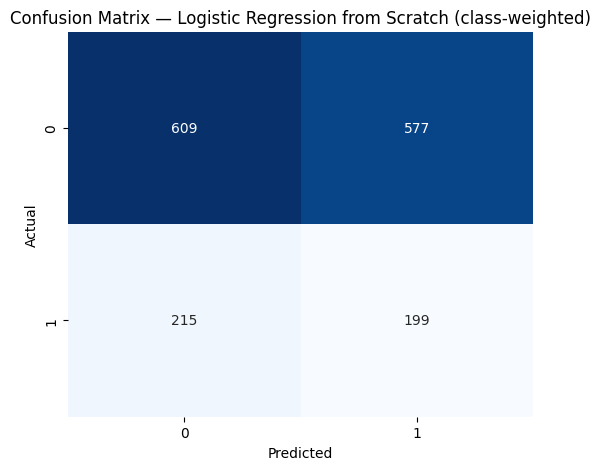

In [29]:
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Logistic Regression from Scratch (class-weighted)")
plt.show()

## Part C — Handling Class Imbalance with SMOTE

In [30]:
!pip install -q imbalanced-learn

Confusion Matrix:
 [[627 559]
 [212 202]]
Accuracy: 0.518125
Precision: 0.26544021024967146
Recall: 0.48792270531400966
F1 Score: 0.34382978723404256


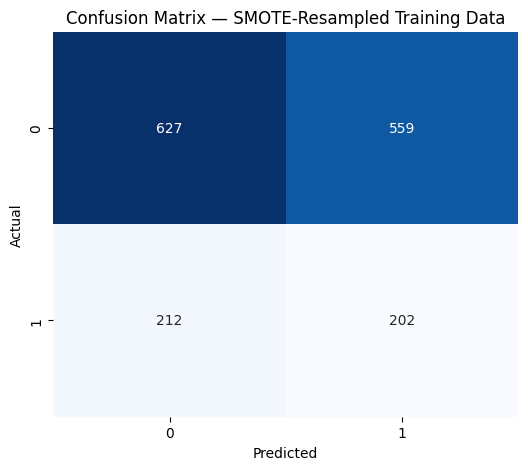

In [31]:
smote = SMOTE(random_state=42)
X_train.columns = X_train.columns.astype(str)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

model = LogisticRegressionScratch(lr=0.01, epochs=2000, use_class_weights=True)
model.fit(X_train_res.astype(float), y_train_res)

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, zero_division=0))
print("Recall:", recall_score(y_test, y_pred, zero_division=0))
print("F1 Score:", f1_score(y_test, y_pred, zero_division=0))

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — SMOTE-Resampled Training Data")
plt.show()

## Part D — Comparison Against scikit-learn's LogisticRegression

Confusion Matrix:
 [[619 567]
 [205 209]]
Accuracy: 0.5175
Precision: 0.2693298969072165
Recall: 0.5048309178743962
F1 Score: 0.35126050420168065


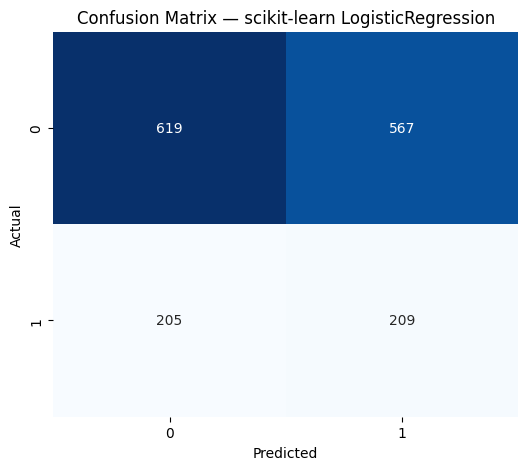

In [32]:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
X_train_res = pd.DataFrame(X_train_res, columns=X_train.columns.astype(str))
X_test.columns = X_test.columns.astype(str)

sk_model = LogisticRegression(max_iter=2000, class_weight="balanced")
sk_model.fit(X_train_res, y_train_res)

y_pred = sk_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, zero_division=0))
print("Recall:", recall_score(y_test, y_pred, zero_division=0))
print("F1 Score:", f1_score(y_test, y_pred, zero_division=0))

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — scikit-learn LogisticRegression")
plt.show()